In [16]:
import sys
sys.path.append('..')
from sklearn.linear_model import LogisticRegression
from src.fista import LogisticLassoFistaCV
from src.data_prep import ColumnSelector
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def plot_coefficients_comparison(beta_sklearn: np.ndarray, beta_fista: np.ndarray, top_k: int = 20):
    max_abs_weights = np.maximum(np.abs(beta_sklearn), np.abs(beta_fista))
    
    top_k = min(top_k, len(max_abs_weights))
    
    top_indices = np.argsort(max_abs_weights)[::-1][:top_k]
    
    b_sk = beta_sklearn[top_indices]
    b_fista = beta_fista[top_indices]
    
    x = np.arange(len(top_indices))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(x - width/2, b_sk, width, label='Scikit-Learn', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, b_fista, width, label='FISTA (Custom)', color='darkorange', edgecolor='black')

    ax.set_ylabel(r'$\beta$ value')
    ax.set_xlabel('Variable')
    ax.set_title(f'Top {top_k} weights comparison')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'X_{i}' for i in top_indices], rotation=45)
    
    ax.legend()
    
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    fig.tight_layout()
    plt.show()

In [70]:
from sklearn.model_selection import train_test_split


prostate = pd.read_csv('../data/processed/prostate.csv')
X = prostate.iloc[:, :-1]
y = prostate.iloc[:, -1]
X_train, X_val, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

n = len(X_train)
reg = 1e-2
C = 1 / (n * reg)

lr_sklearn = LogisticRegression(penalty='l1', l1_ratio=1, C=C, solver='saga', max_iter=20_000, verbose=False, tol=1e-4)
lr_fista = LogisticLassoFistaCV(lambdas=[reg], max_iter=20_000, verbose=False, tol=1e-4)

In [71]:
lr_sklearn.fit(X_train, y_train)

/home/tomek2/studia/semestr_8/aml/projekty/semi-supervised-FISTA-logistic-lasso/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.4084507042253522
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [72]:
lr_fista.fit(X_train, y_train)

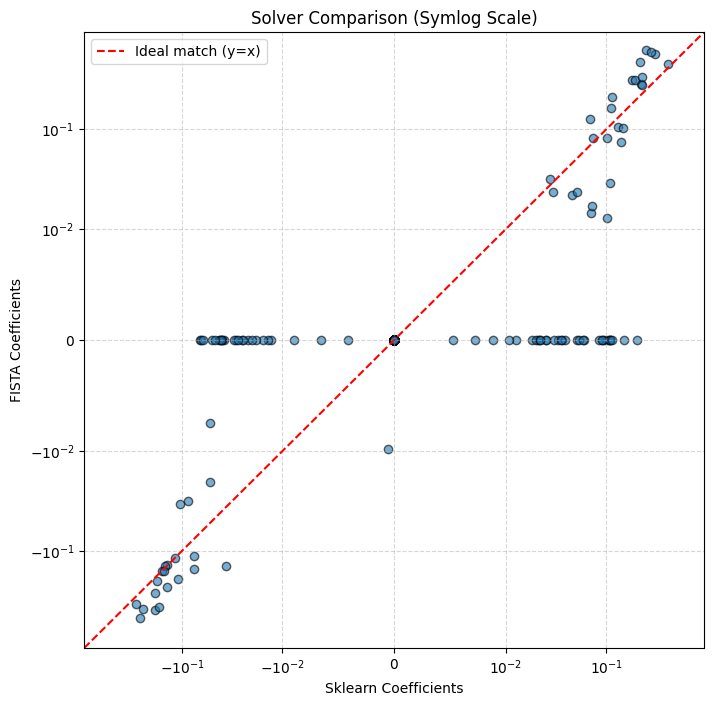

In [75]:
beta_sklearn = lr_sklearn.coef_[0]
beta_fista = lr_fista.best_beta_[1:]

plt.figure(figsize=(8, 8))
plt.scatter(beta_sklearn, beta_fista, alpha=0.6, edgecolor='k')

max_val = np.max(np.abs([beta_sklearn, beta_fista])) * 1.5
limits = [-max_val, max_val]

plt.plot(limits, limits, 'r--', label='Ideal match (y=x)')

plt.xscale('symlog', linthresh=1e-2)
plt.yscale('symlog', linthresh=1e-2)

plt.xlim(limits)
plt.ylim(limits)

plt.xlabel('Sklearn Coefficients')
plt.ylabel('FISTA Coefficients')
plt.title('Solver Comparison (Symlog Scale)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

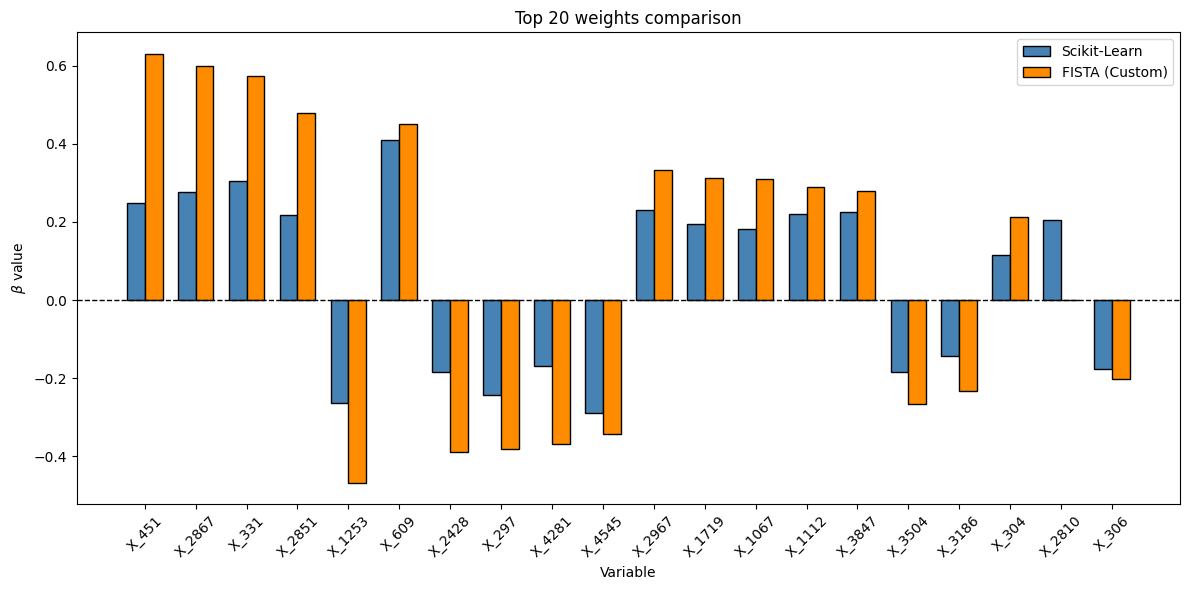

In [77]:
plot_coefficients_comparison(beta_sklearn, beta_fista)

In [61]:
from sklearn.datasets import load_breast_cancer

In [78]:
bc = load_breast_cancer()
X = bc.data
y = bc.target

X_train, X_val, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

n = len(X_train)

reg = 1e-2
C = 1 / (n * reg)

lr_sklearn = LogisticRegression(l1_ratio=1, C=C, solver='saga', max_iter=20_000, verbose=False, tol=1e-4)
lr_fista = LogisticLassoFistaCV(lambdas=[reg], max_iter=20_000, verbose=False, tol=1e-4)

In [63]:
lr_sklearn.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.25125628140703515
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

In [64]:
lr_fista.fit(X_train, y_train)

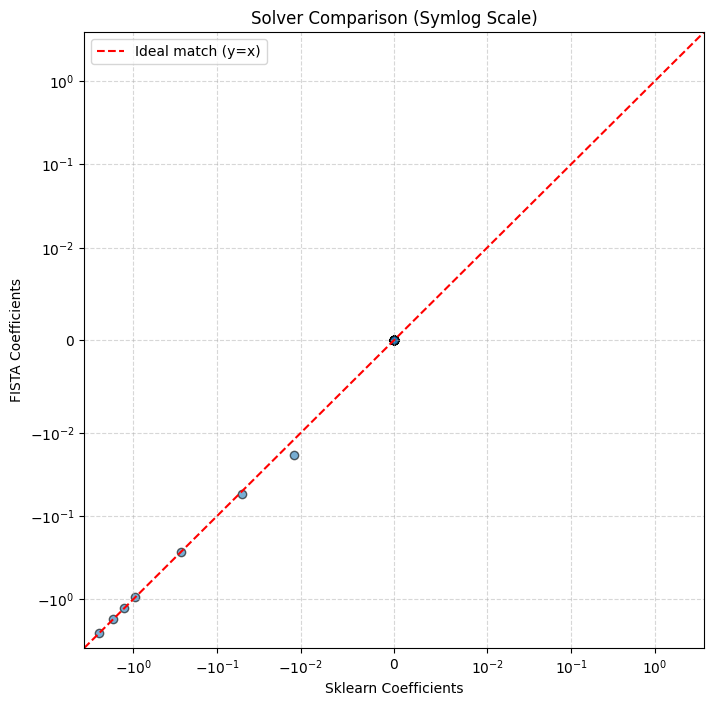

In [68]:
beta_sklearn = lr_sklearn.coef_[0]
beta_fista = lr_fista.best_beta_[1:]

plt.figure(figsize=(8, 8))
plt.scatter(beta_sklearn, beta_fista, alpha=0.6, edgecolor='k')

max_val = np.max(np.abs([beta_sklearn, beta_fista])) * 1.5
limits = [-max_val, max_val]

plt.plot(limits, limits, 'r--', label='Ideal match (y=x)')

plt.xscale('symlog', linthresh=1e-2)
plt.yscale('symlog', linthresh=1e-2)

plt.xlim(limits)
plt.ylim(limits)

plt.xlabel('Sklearn Coefficients')
plt.ylabel('FISTA Coefficients')
plt.title('Solver Comparison (Symlog Scale)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

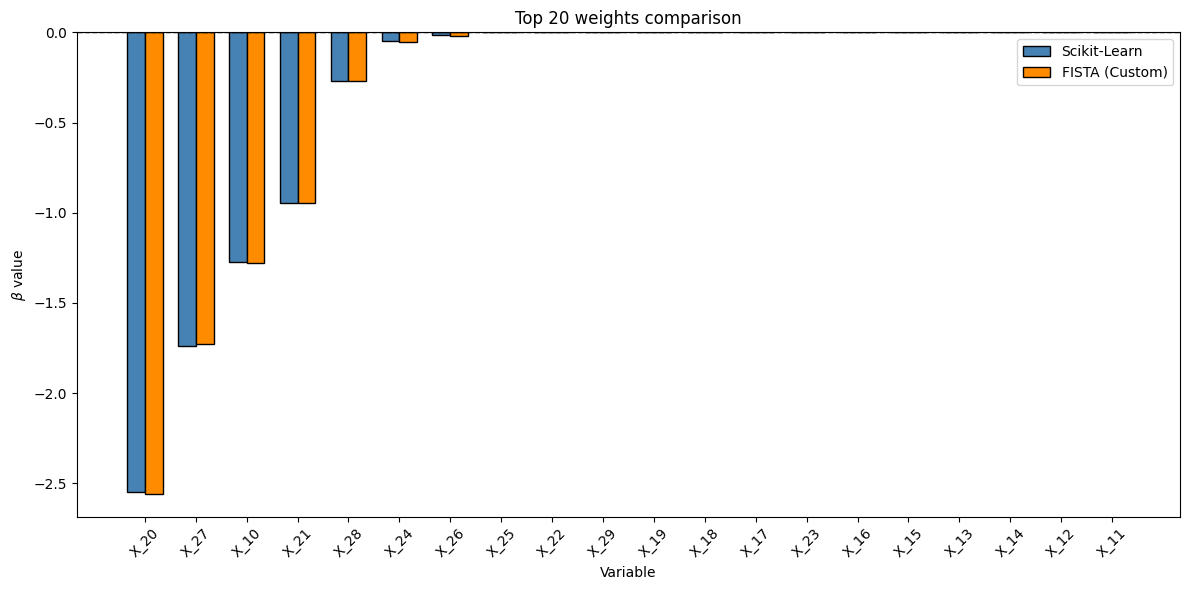

In [66]:
plot_coefficients_comparison(beta_sklearn, beta_fista, top_k=20)